<a href="https://colab.research.google.com/github/SunMoonHexd/inteligencia-artificial-2/blob/main/EjercicioMnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== F1-Score para el dígito 5 ===
F1-Score: 0.8537

=== TABLA DE RESULTADOS (Classification Report) ===
               precision  recall  f1-score    support
Otros números     0.9812  0.9915    0.9863  12737.000
Número 5          0.9043  0.8084    0.8537   1263.000
accuracy          0.9750  0.9750    0.9750      0.975
macro avg         0.9428  0.9000    0.9200  14000.000
weighted avg      0.9743  0.9750    0.9744  14000.000


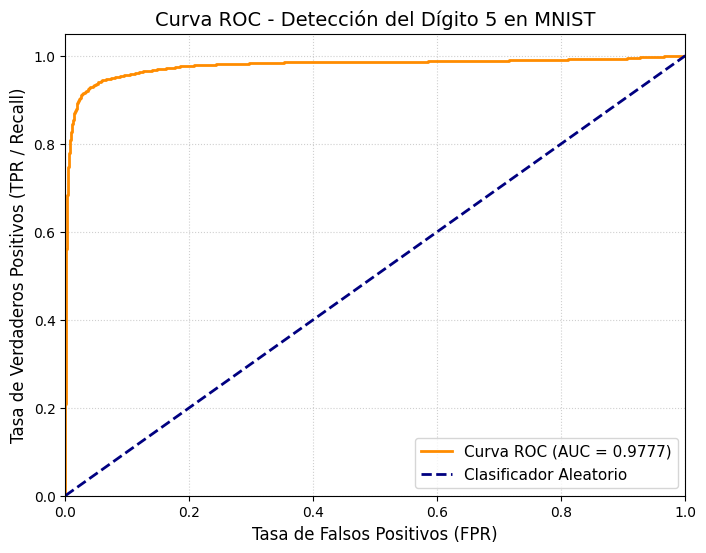

In [1]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_curve, roc_auc_score, confusion_matrix

# ==============================================================================
# 2. CARGA Y PREPARACIÓN DEL DATASET MNIST
# ==============================================================================
# Cargar el conjunto de datos MNIST desde OpenML (70,000 imágenes de 28x28 píxeles)
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Separar las características (X: píxeles) y las etiquetas (y: dígitos del 0 al 9)
X, y = mnist.data, mnist.target

# Convertir las etiquetas de texto a enteros para facilitar su manipulación
y = y.astype(np.uint8)

# Escalar los píxeles de [0, 255] a [0, 1] para mejorar la convergencia del algoritmo
X = X / 255.0

# Define el dígito objetivo que deseas reconocer (en este ejemplo, el número 5)
DIGITO_OBJETIVO = 5

# Crear etiquetas binarias: True (1) si es el dígito objetivo, False (0) si es cualquier otro número
y_binary = (y == DIGITO_OBJETIVO)

# Dividir los datos en conjunto de entrenamiento (80%) y prueba (20%) manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# ==============================================================================
# 3. ENTRENAMIENTO DEL MODELO
# ==============================================================================
# Inicializar la Regresión Logística (max_iter elevado para asegurar la convergencia)
model = LogisticRegression(max_iter=1000, random_state=42)

# Entrenar el modelo con los datos de entrenamiento binarios
model.fit(X_train, y_train)

# ==============================================================================
# 4. PREDICCIONES Y EVALUACIÓN DE MÉTRICAS
# ==============================================================================
# Obtener las predicciones binarias (True/False) en el conjunto de prueba
y_pred = model.predict(X_test)

# Obtener las probabilidades continuas de pertenecer a la clase positiva (necesario para la curva ROC)
y_scores = model.predict_proba(X_test)[:, 1]

# Calcular el F1-Score específico para la detección del dígito objetivo
f1 = f1_score(y_test, y_pred)
print(f"=== F1-Score para el dígito {DIGITO_OBJETIVO} ===")
print(f"F1-Score: {f1:.4f}\n")

# ==============================================================================
# 5. TABLA DE RESULTADOS
# ==============================================================================
# Generar un reporte detallado con Precisión, Recall, F1-Score y Soporte
report_dict = classification_report(
    y_test, y_pred, target_names=[f'Otros números', f'Número {DIGITO_OBJETIVO}'], output_dict=True
)

# Convertir el reporte a un DataFrame de pandas para mostrarlo como una tabla estructurada
df_resultados = pd.DataFrame(report_dict).transpose()

print("=== TABLA DE RESULTADOS (Classification Report) ===")
# Mostrar el dataframe tabulado en la consola
print(df_resultados.round(4))

# ==============================================================================
# 6. GRÁFICO DE LA CURVA ROC
# ==============================================================================
# Calcular la tasa de falsos positivos (fpr), tasa de verdaderos positivos (tpr) y umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calcular el área bajo la curva (AUC - Area Under Curve)
roc_auc = roc_auc_score(y_test, y_scores)

# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Dibujar la curva ROC del modelo
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')

# Dibujar la línea diagonal de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')

# Ajustar límites y etiquetas de los ejes
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
plt.title(f'Curva ROC - Detección del Dígito {DIGITO_OBJETIVO} en MNIST', fontsize=14)

# Mostrar la leyenda y la cuadrícula en el gráfico
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Desplegar la figura en Google Colab
plt.show()